In [28]:
!pip install wordcloud

In [29]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

In [30]:
df = pd.read_csv("amazonreviews.tsv", sep="\t", quoting=3)

In [31]:
df.columns = [c.strip().lower() for c in df.columns]

In [32]:
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,"""Amazing!: This soundtrack is my favorite musi..."
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [33]:
df = df.drop_duplicates(subset=["label","review"])
df = df.dropna(subset=["review"])

In [34]:
df["review"] = df["review"].astype(str).str.lower()
df["review"] = df["review"].apply(lambda x: re.sub(r"http\S+|<.*?>", " ", x))
df["review"] = df["review"].apply(lambda x: re.sub(r"[^a-z0-9\s]", " ", x))
df["review"] = df["review"].str.replace(r"\s+", " ", regex=True).str.strip()

In [35]:
# Map labels to numeric
df["label_num"] = df["label"].map({"neg":0, "pos":1})

In [36]:
#Label Distribution
df["label"].value_counts()

label
neg    5097
pos    4903
Name: count, dtype: int64

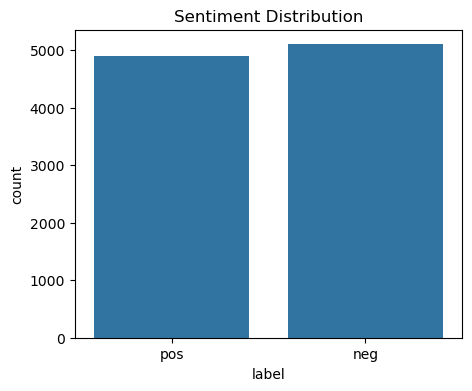

In [37]:
plt.figure(figsize=(5,4))
sns.countplot(x=df["label"])
plt.title("Sentiment Distribution")
plt.show()

In [38]:
# WordCloud for positive / negative words
pos_reviews = " ".join(df[df.label=="pos"]["review"].tolist())
neg_reviews = " ".join(df[df.label=="neg"]["review"].tolist())

(np.float64(-0.5), np.float64(499.5), np.float64(299.5), np.float64(-0.5))

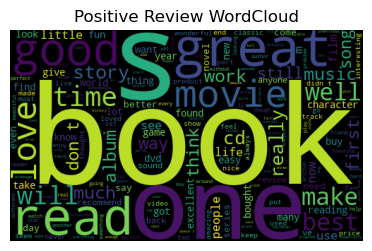

In [39]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(WordCloud(width=500, height=300).generate(pos_reviews))
plt.title("Positive Review WordCloud")
plt.axis("off")

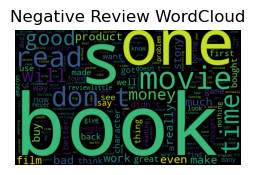

In [40]:
plt.subplot(1,2,2)
plt.imshow(WordCloud(width=500, height=300).generate(neg_reviews))
plt.title("Negative Review WordCloud")
plt.axis("off")
plt.show()

In [41]:
X = df["review"]
y = df["label_num"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [43]:
# MODEL PIPELINE 
tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1,2), max_df=0.9, min_df=3)

In [44]:
model = LogisticRegression(max_iter=1000)

In [45]:
grid = {"C":[0.5,1,2,3]}

In [46]:
clf = GridSearchCV(model, grid, cv=3, scoring="f1")
clf.fit(tfidf.fit_transform(X_train), y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.5, 1, ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [47]:
best_model = clf.best_estimator_

In [48]:
# EVALUATION 
X_test_tfidf = tfidf.transform(X_test)
y_pred = best_model.predict(X_test_tfidf)

print("\nBest Params:", clf.best_params_)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nF1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Best Params: {'C': 3}

Accuracy: 0.8585

F1 Score: 0.8532918610679109

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86      1037
           1       0.85      0.85      0.85       963

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



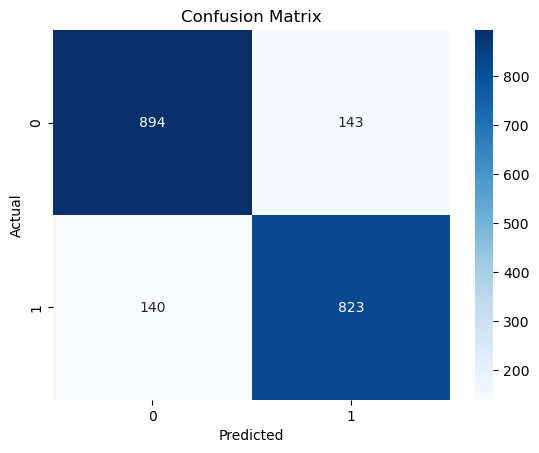

In [49]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [50]:
# SAMPLE PREDICTION 
sample_text = "This product is amazing and works perfectly!"
sample_vec = tfidf.transform([sample_text])
pred = best_model.predict(sample_vec)[0]

print("\nSample Review:", sample_text)
print("Predicted Sentiment:", "Positive" if pred==1 else "Negative")


Sample Review: This product is amazing and works perfectly!
Predicted Sentiment: Positive
